[[[ 31  32  32 ...  23  22  20]
  [ 32  33  32 ...  22  22  23]
  [ 34  33  31 ...  19  20  28]
  ...
  [ 70  70  74 ...  49  85  87]
  [ 77  75  76 ...  21  41  49]
  [ 73  73  75 ...  20  23  39]]

 [[ 53  57  57 ...  28  28  29]
  [ 55  60  58 ...  29  29  29]
  [ 58  59  56 ...  29  27  32]
  ...
  [ 52  53  53 ...  39  67  72]
  [ 57  57  56 ...  23  39  56]
  [ 56  55  56 ...  30  29  46]]

 [[ 23  24  22 ...  18  16  17]
  [ 22  25  25 ...  18  15  16]
  [ 22  24  23 ...  15  14  15]
  ...
  [ 32  32  33 ...  23  41  47]
  [ 34  35  36 ...  15  22  28]
  [ 36  33  33 ...  14  12  22]]

 [[255 255 255 ... 255 255 255]
  [255 255 255 ... 255 255 255]
  [255 255 255 ... 255 255 255]
  ...
  [255 255 255 ... 255 255 255]
  [255 255 255 ... 255 255 255]
  [255 255 255 ... 255 255 255]]]
(4, 794, 1034)


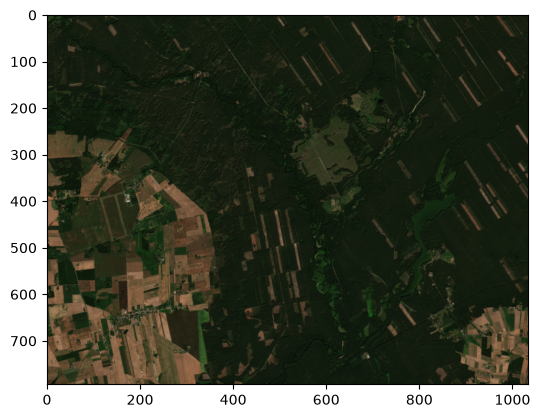

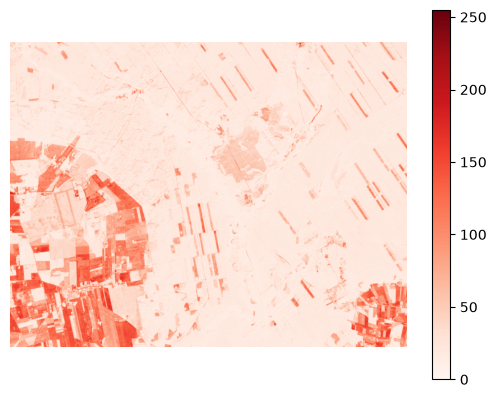

In [33]:
import rasterio
import numpy as np
import matplotlib.pyplot as plt

# Odczyt rastra:
path_to_files = "../dane/raster/"
with rasterio.open(path_to_files+"tucholski_fragment.tif") as src:
    raster = src.read()
print(raster) # Co jest wynikiem print?
print(raster.shape) # Jak interpretować te dane?

# Wyświetlanie rastra:
rgb = np.moveaxis(raster[0:3], 0, -1)
plt.imshow(rgb)
plt.show()

# Czym będzie się różnić poniższy obraz od poprzedniego?
plt.imshow(rgb[:,:,0], cmap="Reds")
plt.colorbar()
plt.axis("off")
plt.show()

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [709..18832].


[[[1221 1237 1256 ... 1238 1229 1204]
  [1228 1258 1286 ... 1238 1210 1199]
  [1261 1282 1278 ... 1235 1211 1220]
  ...
  [1249 1252 1248 ... 1375 1382 1361]
  [1253 1249 1247 ... 1379 1366 1362]
  [1235 1245 1251 ... 1370 1341 1354]]

 [[1368 1339 1376 ... 1457 1431 1417]
  [1352 1360 1402 ... 1453 1416 1411]
  [1381 1414 1391 ... 1437 1406 1416]
  ...
  [1359 1348 1343 ... 1547 1536 1526]
  [1357 1353 1348 ... 1544 1552 1540]
  [1348 1357 1359 ... 1544 1538 1542]]

 [[1337 1299 1324 ... 1326 1312 1334]
  [1333 1349 1369 ... 1317 1307 1334]
  [1334 1345 1358 ... 1319 1321 1330]
  ...
  [1241 1220 1221 ... 1259 1254 1260]
  [1222 1206 1225 ... 1253 1261 1253]
  [1232 1233 1229 ... 1254 1242 1250]]]


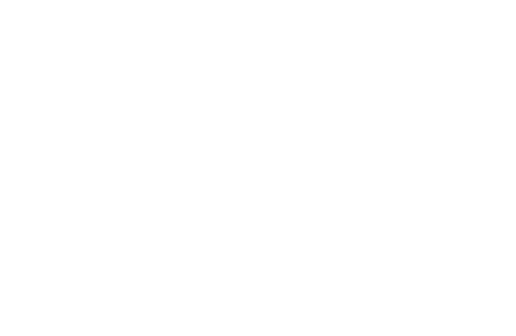

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [709..18832].


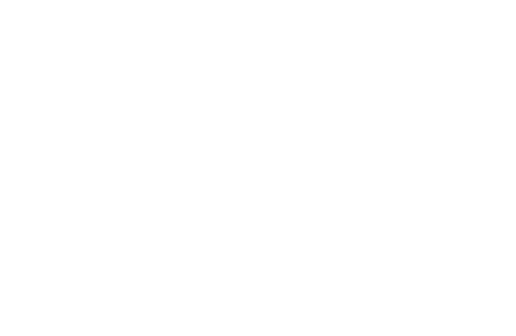

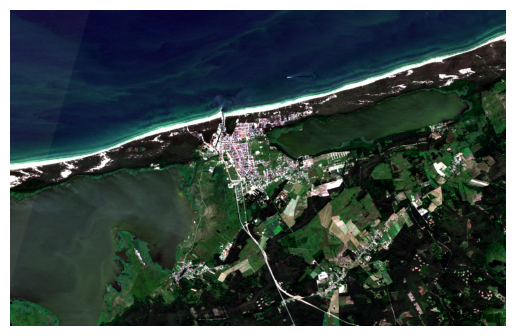

In [ ]:
path2 = path_to_files+"sentinel-2-l2a_2026-06-26_S2C_MSIL2A_20260626T101021_R022_T33UXA_20260626T152309/sentinel-2-l2a_2026-06-26_S2C_MSIL2A_20260626T101021_R022_T33UXA_20260626T152309_"

with rasterio.open(path2 + "B04.tif") as src:
    red = src.read(1)

with rasterio.open(path2 + "B03.tif") as src:
    green = src.read(1)

with rasterio.open(path2 + "B02.tif") as src:
    blue = src.read(1)


rgb_stacked = np.stack([red, green, blue])
print(rgb_stacked) # Połączone kanały z 3 plików

raster_rgb = np.moveaxis(rgb_stacked, 0, -1)

plt.imshow(raster_rgb)
plt.axis("off")
plt.show()
# Dlaczego nie widzimy obrazu?

# Normalizacja danych #1:
raster_rgb1 = raster_rgb / raster_rgb.max() * 255
raster_rgb1 = raster_rgb1.astype(np.uint8)

plt.imshow(raster_rgb1) # Wartości 0-255
plt.axis("off")
plt.show()

# Normalizacja danych #2:
raster_rgb2 = raster_rgb.astype(float).copy()
for i in range(3):
    low = np.percentile(raster_rgb2[:, :, i], 2)
    high = np.percentile(raster_rgb2[:, :, i], 98)

    raster_rgb2[:, :, i] = np.clip(
        (raster_rgb2[:, :, i] - low) / (high - low),
        0,
        1
    )

plt.imshow(raster_rgb2) # Wartości 0.0 - 1.0
plt.axis("off")
plt.show()
# Jakie obrazy wyszłyby gdybyśmy zmienili zakres normalizacji #2 z 2-98 na inne percentyle?